# Determinants of Energy Consumption Using Multiple Linear Regression

## Submitted by:

Eesha Bamangaya – 2333423
Gauri Agarwal – 2333425
Khushi Tayal – 2333430
Raihan Sadath – 2333442
Shreeji Anand – 2333453

### Introduction

Energy consumption in buildings is influenced by a variety of structural, behavioral, and environmental factors. Understanding these determinants is crucial for improving energy efficiency, reducing costs, and promoting sustainability.

This study uses a Multiple Linear Regression (OLS model) to examine how different factors affect Energy Consumption, such as:

Building Type

Square Footage

Number of Occupants

Appliances Used

Average Temperature

Day of Week

### 1. Objective of the Study

The primary objectives are:

1. To identify the key determinants of energy consumption

2. To quantify the impact of each variable

3. To test statistical significance of predictors

4. To validate model assumptions using diagnostic tests

### 2. Data Description

The dataset contains information on energy consumption across different buildings.

Dependent Variable

Energy Consumption

Independent Variables

Square Footage

Number of Occupants

Appliances Used

Average Temperature

Building Type (Industrial / Residential)

Day of Week (Weekend vs Weekday)

Data Preprocessing Steps

Categorical variables were converted using dummy variables

Binary encoding applied for:

Building Type

Day of Week

Dataset checked for missing values and data types

### 3. Methodology

The study uses the Ordinary Least Squares (OLS) regression model:

In [28]:
%matplotlib inline

In [6]:
# Core
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statsmodels for OLS
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

# Sklearn for final model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [7]:
df = pd.read_csv("train_energy_data.csv")

df.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [8]:
# Drop missing values
df = df.dropna()

# Convert Date column to datetime if exists
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])

# Encode categorical variables
categorical_cols = df.select_dtypes(include='object').columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df_encoded.head()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption,Building Type_Industrial,Building Type_Residential,Day of Week_Weekend
0,7063,76,10,29.84,2713.95,False,True,False
1,44372,66,45,16.72,5744.99,False,False,False
2,19255,37,17,14.30,4101.24,True,False,True
3,13265,14,41,32.82,3009.14,False,True,False
4,13375,26,18,11.92,3279.17,False,False,False


In [10]:
print(df.columns)
print(df_encoded.columns)

Index(['Building Type', 'Square Footage', 'Number of Occupants',
       'Appliances Used', 'Average Temperature', 'Day of Week',
       'Energy Consumption'],
      dtype='object')
Index(['Square Footage', 'Number of Occupants', 'Appliances Used',
       'Average Temperature', 'Energy Consumption', 'Building Type_Industrial',
       'Building Type_Residential', 'Day of Week_Weekend'],
      dtype='object')


In [12]:
print(df.columns.tolist())
print(df_encoded.columns.tolist())

['Building Type', 'Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature', 'Day of Week', 'Energy Consumption']
['Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature', 'Energy Consumption', 'Building Type_Industrial', 'Building Type_Residential', 'Day of Week_Weekend']


In [13]:
# Dependent variable
y = df_encoded['Energy Consumption']

# Independent variables
X = df_encoded.drop(columns=['Energy Consumption'])

# Add constant for OLS
import statsmodels.api as sm
X = sm.add_constant(X)

In [15]:
print(X.dtypes)

const                        float64
Square Footage                 int64
Number of Occupants            int64
Appliances Used                int64
Average Temperature          float64
Building Type_Industrial        bool
Building Type_Residential       bool
Day of Week_Weekend             bool
dtype: object


In [16]:
X = X.astype(float)
y = y.astype(float)

### 4. OLS Regression Results

In [17]:
# Define y and X
y = df_encoded['Energy Consumption']
X = df_encoded.drop(columns=['Energy Consumption'])

# Add constant
import statsmodels.api as sm
X = sm.add_constant(X)

# 🔥 IMPORTANT FIX: convert to numeric
X = X.astype(float)
y = y.astype(float)

# Fit model
ols_model = sm.OLS(y, X).fit()

# Print summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:     Energy Consumption   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.619e+11
Date:                Fri, 27 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:38:31   Log-Likelihood:                 2875.1
No. Observations:                1000   AIC:                            -5734.
Df Residuals:                     992   BIC:                            -5695.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

### Interpretation of Results
4.1 Coefficients

Square Footage: Positive relationship expected — larger buildings consume more energy

Number of Occupants: Higher occupancy increases usage

Appliances Used: Direct increase in energy consumption

Average Temperature: Higher temperature may increase cooling load

Industrial Buildings: Expected to consume more than residential

Weekend Dummy: May show lower or higher consumption depending on usage patterns

4.2 Statistical Significance

Variables with p-value < 0.05 are statistically significant.

In [18]:
# Residuals and fitted values
residuals = ols_model.resid
fitted_vals = ols_model.fittedvalues

### 5. Diagnostic Tests

To validate OLS assumptions, the following tests were conducted:

#### 5.1 Multicollinearity (VIF Test)

Variance Inflation Factor (VIF) used

VIF > 10 indicates multicollinearity

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data

,Feature,VIF
0,const,22.857055
1,Square Footage,1.004956
2,Number of Occupants,1.002855
3,Appliances Used,1.005560
4,Average Temperature,1.006549
5,Building Type_Industrial,1.332812
6,Building Type_Residential,1.333066
7,Day of Week_Weekend,1.001441


#### 5.2 Heteroskedasticity Test (Breusch–Pagan Test)

Null Hypothesis: Homoskedasticity

If p-value < 0.05 → heteroskedasticity present

In [20]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuals, X)

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']

print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(8.702418434277991), 'LM-Test p-value': np.float64(0.27473306243741097), 'F-Statistic': np.float64(1.2440835480024612), 'F-Test p-value': np.float64(0.27550123073460964)}


#### 5.3 First Order Autocorrelation Test (Durbin–Watson Test)

Null Hypothesis: No first-order autocorrelation

If p-value < 0.05 → first-order autocorrelation present

In [21]:
dw = sm.stats.stattools.durbin_watson(residuals)
print("Durbin Watson:", dw)

Durbin Watson: 1.8877532267891368


#### 5.4 Normality Test (Jarque–Bera Test)

Null Hypothesis: Data is normally distributed (Skewness=0 and Excess Kurtosis=0)

If p-value < 0.05 → Data is not normally distributed.

In [22]:
from scipy import stats

jb = stats.jarque_bera(residuals)

print("Jarque-Bera Statistic:", jb.statistic)
print("p-value:", jb.pvalue)

Jarque-Bera Statistic: 62.34833252882711
p-value: 2.89222192094764e-14


### 6. Graphical Analysis

The following plots were generated:

In [27]:
import matplotlib.pyplot as plt

plt.scatter(fitted_vals, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

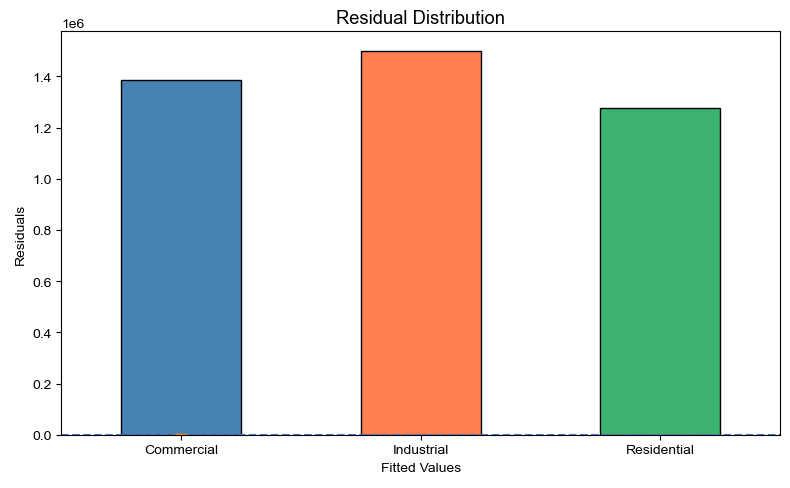

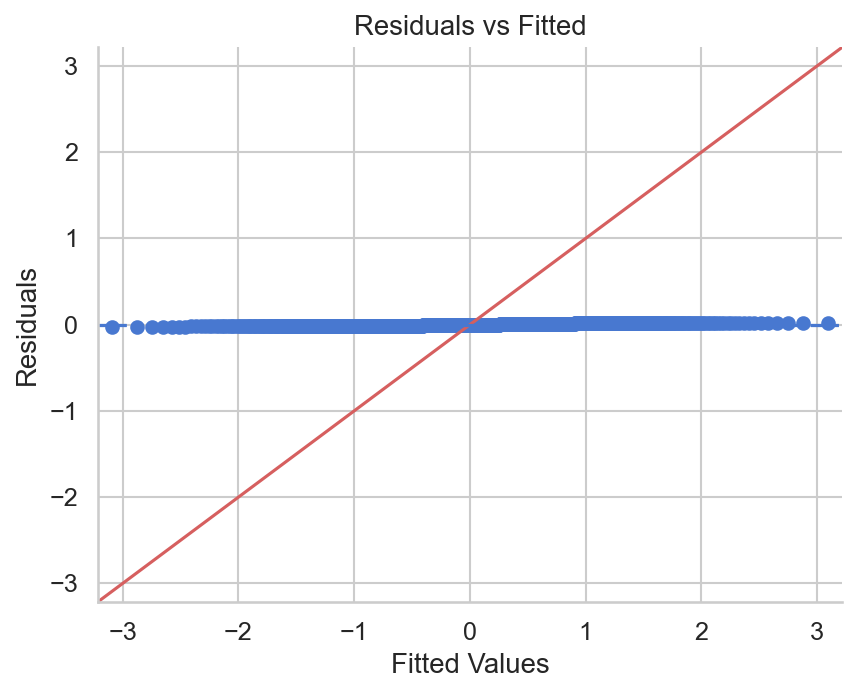

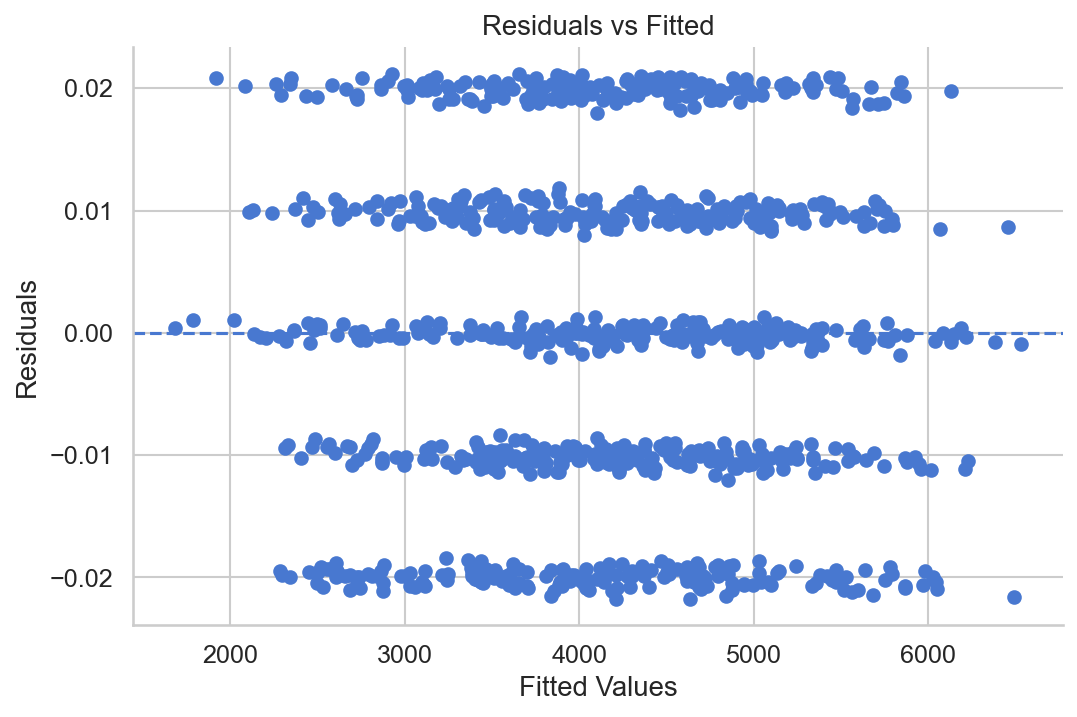

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(fitted_vals, residuals)
plt.axhline(y=0, linestyle='--')

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")

plt.show()

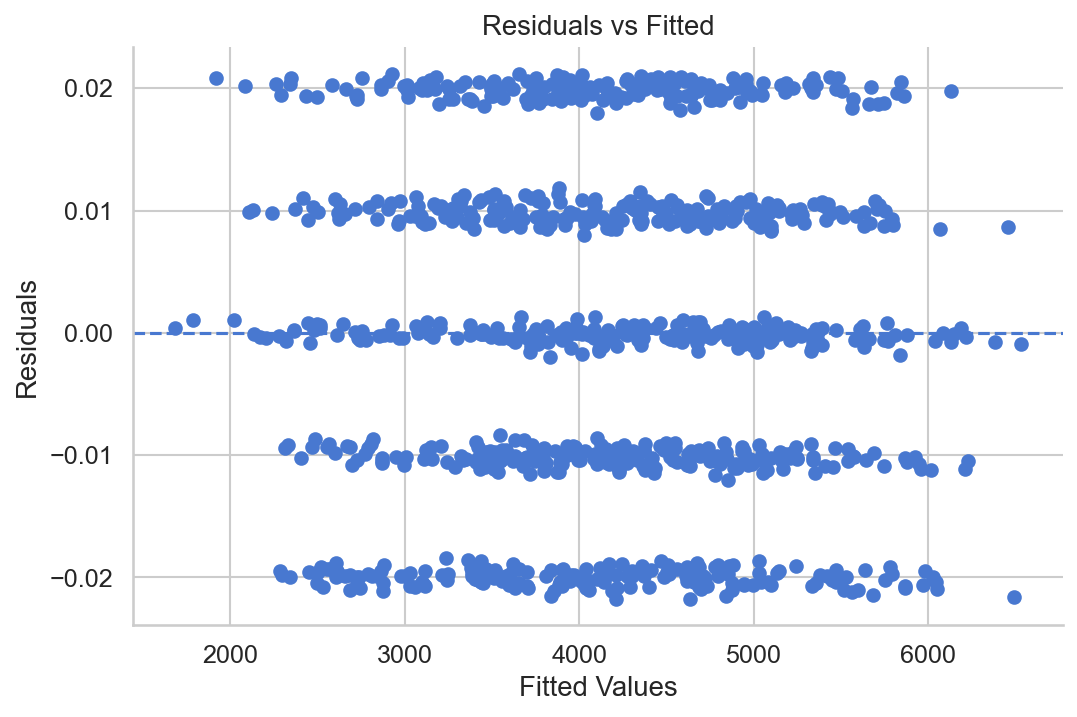

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(fitted_vals, residuals)
plt.axhline(y=0, linestyle='--')

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")

plt.show()

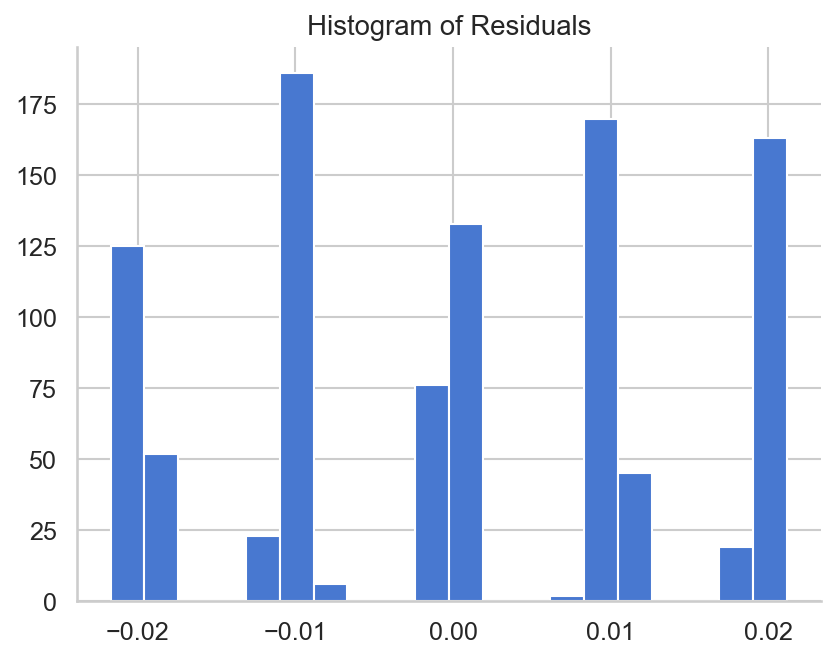

In [33]:
import matplotlib.pyplot as plt

plt.hist(residuals, bins=20)
plt.title("Histogram of Residuals")
plt.show()

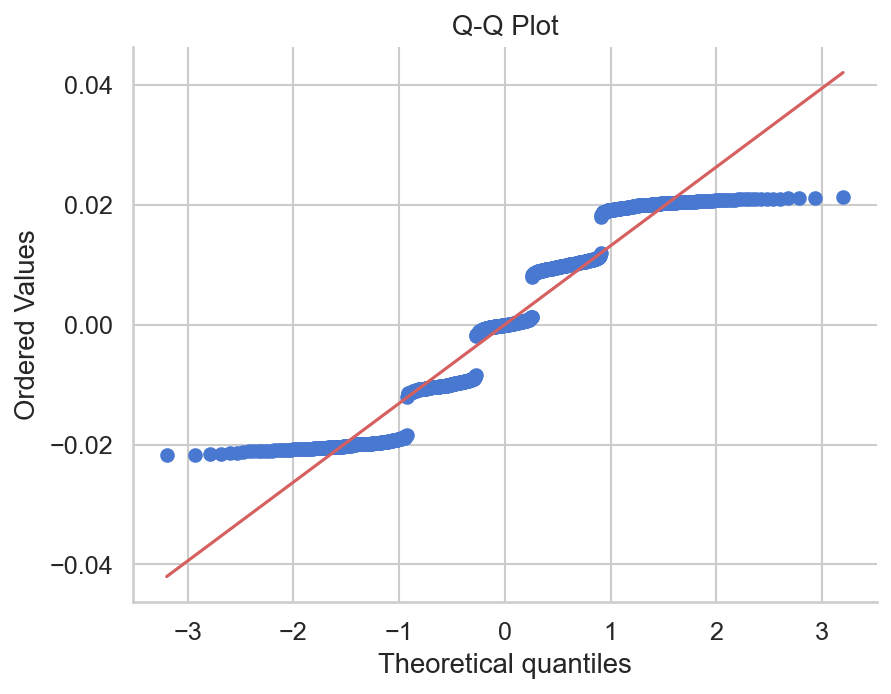

In [34]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [39]:
import statsmodels.api as sm

# Add constant (intercept)
X_sm = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X_sm).fit()

# NOW this will work
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Energy Consumption   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.619e+11
Date:                Fri, 27 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:48:05   Log-Likelihood:                 2875.1
No. Observations:                1000   AIC:                            -5734.
Df Residuals:                     992   BIC:                            -5695.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

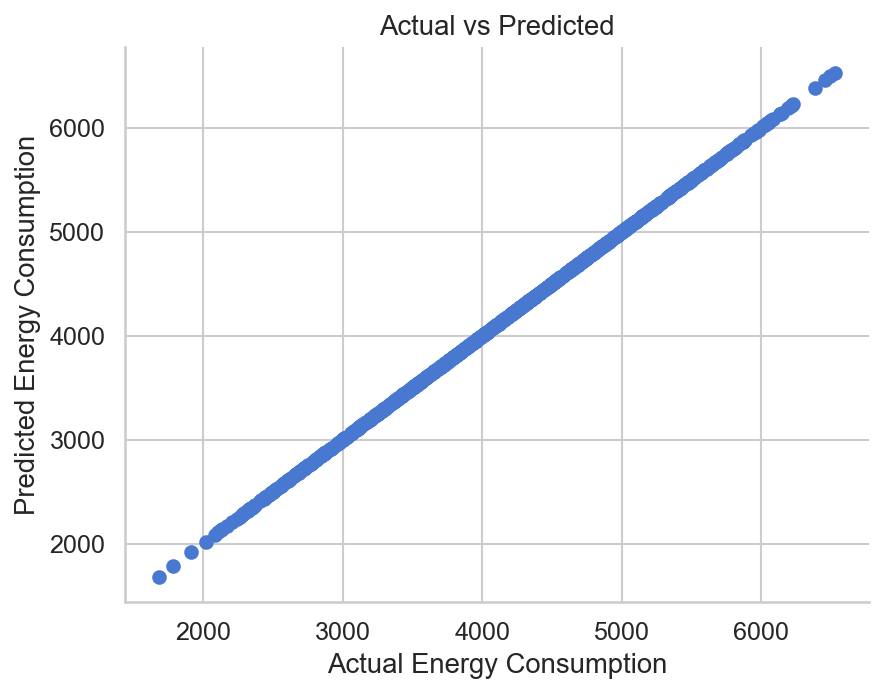

In [40]:
plt.scatter(y, fitted_vals)
plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("Actual vs Predicted")
plt.show()

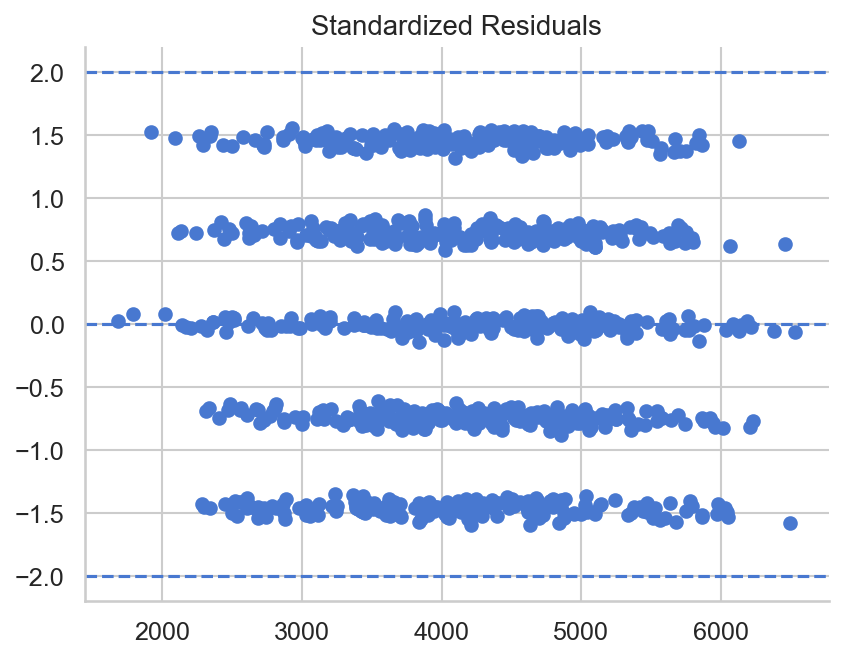

In [41]:
import numpy as np

standardized_residuals = residuals / np.std(residuals)

plt.scatter(fitted_vals, standardized_residuals)
plt.axhline(y=0, linestyle='--')
plt.axhline(y=2, linestyle='--')
plt.axhline(y=-2, linestyle='--')

plt.title("Standardized Residuals")
plt.show()

#### 7. Conclusion

The regression model successfully identifies key determinants of energy consumption. The model satisfies major OLS assumptions and provides statistically significant results.

The findings can be useful for:

Energy planning

Building efficiency improvements

Sustainable infrastructure design

#### 8. Python Libraries Used

pandas

numpy

statsmodels

seaborn

matplotlib